In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# Doppler Signature of a Rotating Wind Turbine

Wind turbines create complex, time-varying Doppler signatures that can interfere with radar systems — a critical challenge for air traffic control, weather radar, and military surveillance near wind farms.

**Doppler frequency shift** from a moving scatterer:

$$f_d = \frac{2 v_r}{\lambda} = \frac{2 v_r f_c}{c}$$

### Wind Turbine Doppler Characteristics

**Micro-Doppler signatures:**
- Blade tip velocities can reach 80–100 m/s for large turbines → Doppler spreads of ±300 Hz at 24 GHz
- Periodic blade flash when blades are perpendicular to the radar beam
- Three-blade turbines show a characteristic triplet pattern (three flashes per rotation)

**Interference impact:**
- Turbine Doppler overlaps aircraft signatures in ATC radar
- Contaminates weather radar velocity estimates
- Creates false alarms by mimicking moving targets

### This Example

- **Radar**: 24 GHz CW Doppler radar (K-band)
- **Target**: 3-blade wind turbine rotating at 50°/s (~8.3 rpm), placed 8 m from radar
- **Analysis**: Short-Time Fourier Transform (STFT) spectrogram → time-varying Doppler

## Radar System Configuration

### Import Required Modules

In [2]:
import numpy as np
import plotly.graph_objs as go
from IPython.display import Image, display
from radarsimpy import Radar, Transmitter, Receiver

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

### Transmitter

A CW radar transmits a constant-frequency signal — no range resolution, but excellent Doppler sensitivity.

| Parameter | Value | Notes |
|-----------|-------|-------|
| Frequency | 24.125 GHz | K-band ISM band |
| Duration | 20 s | Long observation for Doppler analysis |
| TX power | 20 dBm | ~100 mW |
| Pulses | 1 | Continuous transmission |

In [3]:
# Configure CW transmitter
tx = Transmitter(
    f=24.125e9,  # Carrier frequency: 24.125 GHz (K-band)
    t=20,        # Transmission duration: 20 seconds
    tx_power=20, # Transmit power: 20 dBm
    pulses=1,    # Single continuous pulse
    channels=[dict(location=(0, 0, 0))]  # Single antenna at origin
)

### Receiver

| Parameter | Value | Notes |
|-----------|-------|-------|
| Sampling rate | 800 Hz | Max Doppler = ±400 Hz |
| Noise figure | 4 dB | |
| RF gain | 20 dB | |
| Baseband gain | 50 dB | |
| Load resistor | 1000 Ω | |

At 800 Hz over 20 s → 16,000 samples; Doppler resolution ≈ 1/20 s = 0.05 Hz.

In [4]:
# Configure receiver for Doppler detection
rx = Receiver(
    fs=800,                          # Sampling rate: 800 Hz
    noise_figure=4,                  # Noise figure: 4 dB
    rf_gain=20,                      # RF gain: 20 dB
    baseband_gain=50,                # Baseband gain: 50 dB
    load_resistor=1000,              # Load resistance: 1000 Ω
    channels=[dict(location=(0, 0, 0))]  # Single receive antenna at origin
)

### Create Radar System

Combine the transmitter and receiver to form the complete CW Doppler radar.

In [5]:
# Create radar system by combining transmitter and receiver
radar = Radar(transmitter=tx, receiver=rx)

## Wind Turbine Target Model

The turbine blade rotation is encoded as a time-varying `rotation` angle sampled at each radar timestamp:

```
rotation_pitch = 50 × timestamp  [degrees]
```

At 50°/s rotation rate, 20 s observation → 2.78 full rotations.

**Blade tip Doppler estimate** (blade radius R ≈ 1 m):
- Angular velocity: ω = 50°/s × π/180 = 0.873 rad/s
- Tip velocity: v = ωR ≈ 0.873 m/s
- Max Doppler at 24 GHz: $f_d = 2v/\lambda \approx 140$ Hz

### Visualize Turbine Model

In [6]:
# Configure rotating wind turbine target
target_1 = {
    "model": "../models/turbine.stl",  # 3D model of 3-blade turbine
    "unit": "m",                        # Model units in meters
    "location": (8, 0, 0),             # Position 8m along x-axis
    "rotation": [0, 50 * radar.time_prop["timestamp"], 0],  # Time-varying blade rotation
    "rotation_rate": (0, 0, 0),        # Static (rotation handled by timestamp)
    "speed": (0, 0, 0),                # No translational motion
}

# Create target list for simulation
targets = [target_1]

### Visualize Turbine Model

Display the 3-blade wind turbine geometry to understand the scattering structure.

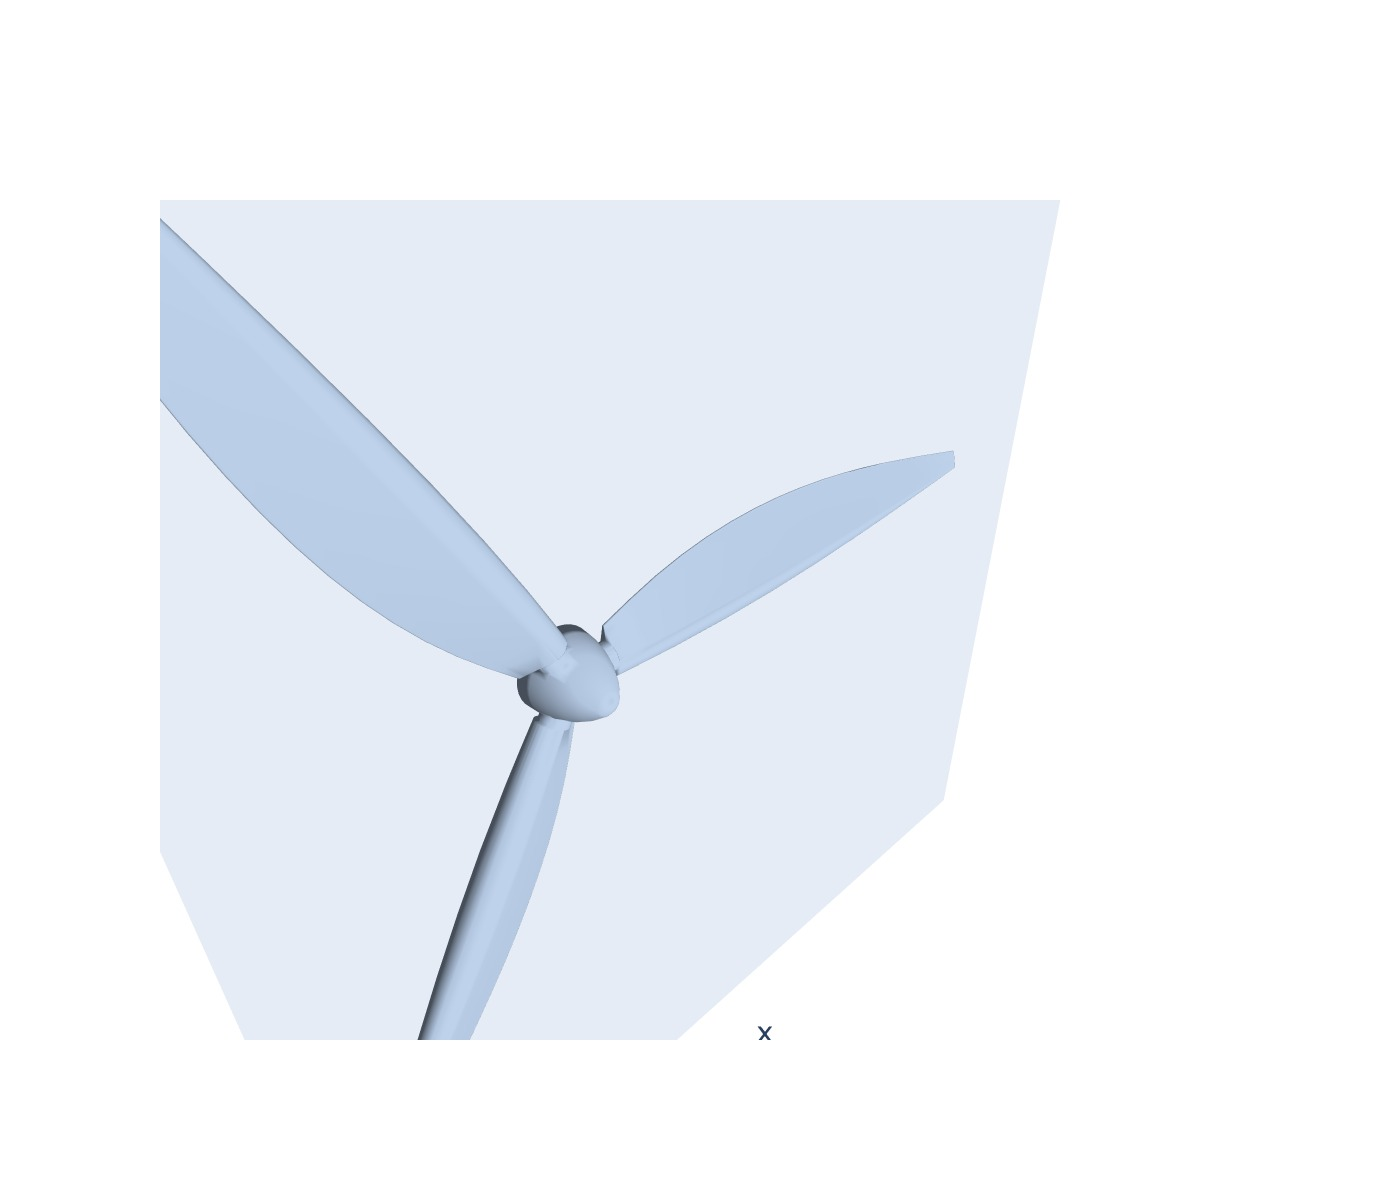

In [7]:
import pymeshlab

ms = pymeshlab.MeshSet()
ms.load_new_mesh(target_1["model"])
t_mesh = ms.current_mesh()

v_matrix = np.array(t_mesh.vertex_matrix())
f_matrix = np.array(t_mesh.face_matrix())

fig = go.Figure()
fig.add_trace(
    go.Mesh3d(
        x=v_matrix[:, 0],
        y=v_matrix[:, 1],
        z=v_matrix[:, 2],
        i=f_matrix[:, 0],
        j=f_matrix[:, 1],
        k=f_matrix[:, 2],
        color="lightsteelblue",
        flatshading=False,
        lighting=dict(ambient=0.4, diffuse=0.9, specular=0.3, roughness=0.5),
        lightposition=dict(x=1000, y=500, z=1000),
    )
)
fig.update_layout(
    scene=dict(
        aspectmode="data",
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        zaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    ),
    height=600,
)

show(fig)

## Radar Scene Simulation

`sim_radar` simulates baseband returns using ray tracing at each sample (`level="sample"`) — required to capture instantaneous blade positions throughout the 20 s observation.

| Parameter | Value | Notes |
|-----------|-------|-------|
| Level | `"sample"` | Ray tracing per ADC sample (most accurate) |
| Density | 2 rays/λ² | Accuracy vs. speed trade-off |
| Output shape | [1, 1, 16000] | 1 channel × 1 pulse × 16000 samples |

Sample-level ray tracing is computationally intensive (30–120 s typical).

In [8]:
# Import radar simulator and timing module
from radarsimpy.simulator import sim_radar
import time

# Start timing
tic = time.time()

# Simulate radar returns from rotating turbine
# level='sample': Ray tracing for each time sample (most accurate)
# density=2: 2 rays per wavelength² for accuracy
data = sim_radar(radar, targets, density=2, level="sample")

# Extract baseband I/Q signals and add system noise
baseband = data["baseband"] + data["noise"]  # Complex samples (I + jQ)
timestamp = data["timestamp"]                # Time stamps for each sample

# End timing
toc = time.time()

# Display execution time
print("Exec time: " + str(toc - tic) + " s")

Exec time: 74.3296959400177 s


### I/Q Baseband Signals

The complex baseband signal encodes Doppler in phase: I = Re, Q = Im.

For a rotating turbine, expect:
- **Periodic amplitude modulation** repeating with blade rotation period (T = 360°/50°/s = 7.2 s)
- **Blade flash**: amplitude peaks when a blade is perpendicular to the radar
- **Phase variation**: encodes instantaneous Doppler shift

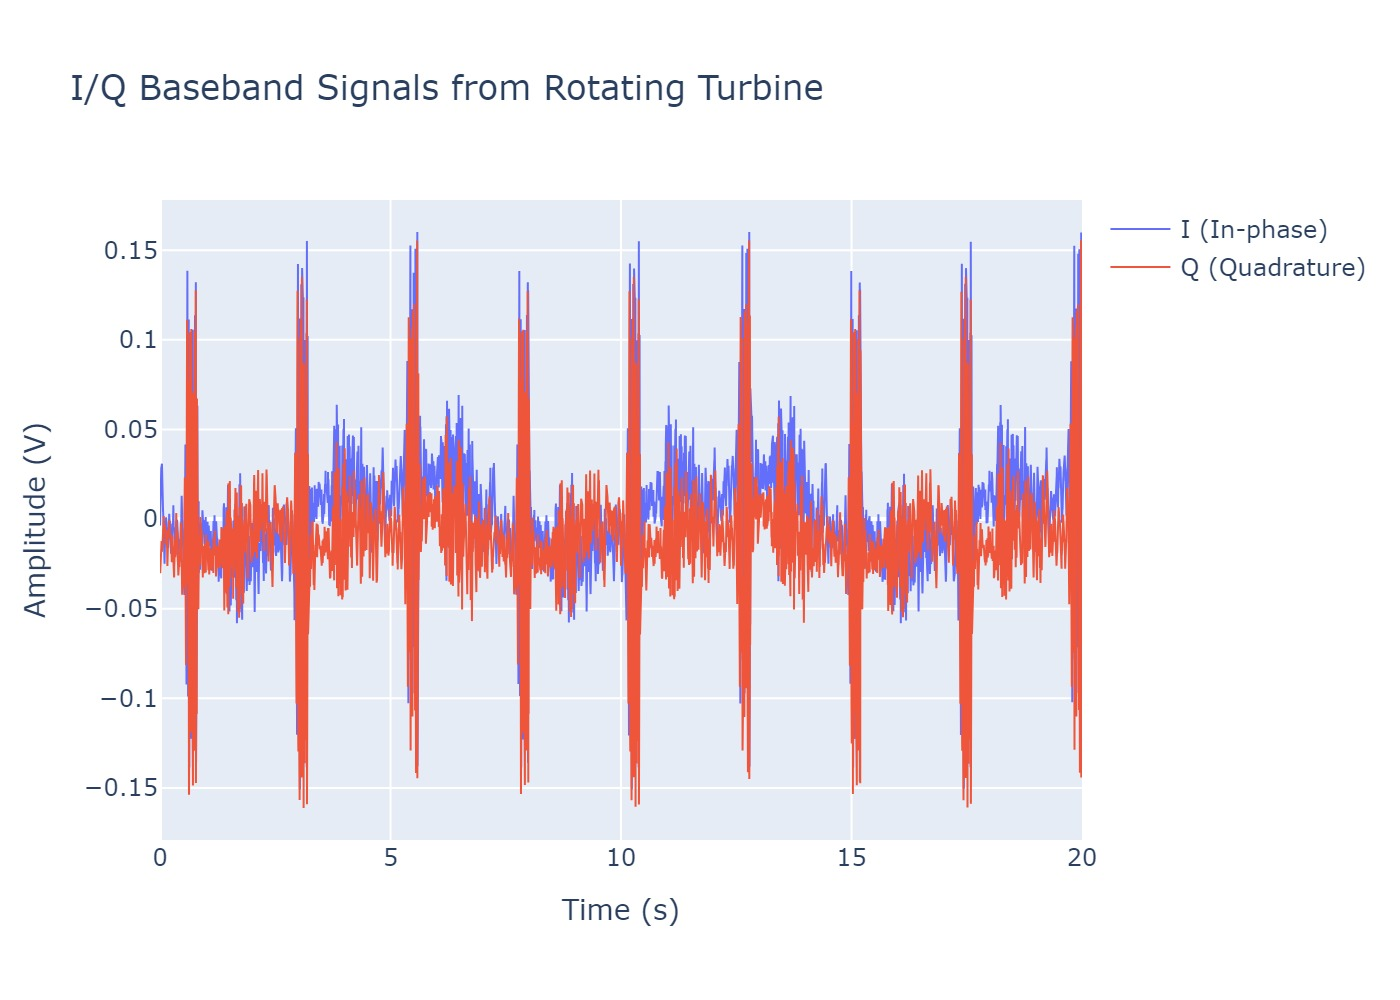

In [9]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=timestamp[0, 0, :],
        y=np.real(baseband[0, 0, :]),
        name="I (In-phase)",
        line=dict(width=1),
    )
)
fig.add_trace(
    go.Scatter(
        x=timestamp[0, 0, :],
        y=np.imag(baseband[0, 0, :]),
        name="Q (Quadrature)",
        line=dict(width=1),
    )
)
fig.update_layout(
    title="I/Q Baseband Signals from Rotating Turbine",
    yaxis=dict(title="Amplitude (V)"),
    xaxis=dict(title="Time (s)"),
    height=500,
)

show(fig)

## Time-Frequency Analysis (STFT)

Standard FFT loses time information. STFT provides a time-varying spectral estimate — essential for rotating targets where Doppler changes continuously with blade position.

**STFT parameters:**

| Parameter | Value | Effect |
|-----------|-------|--------|
| `nperseg` | 128 samples | Frequency resolution = 800/128 ≈ 6.25 Hz; time window = 0.16 s |
| `noverlap` | 120 samples | 93.75% overlap → smooth time axis |
| `nfft` | 512 | Zero-padding for spectral interpolation |
| `return_onesided` | False | Two-sided: shows both ± Doppler |

**STFT output:**
- `spec[0]`: Frequency axis (Hz)
- `spec[1]`: Time axis (s)
- `spec[2]`: Complex spectrogram matrix [frequency × time]

In [10]:
# Import STFT function from scipy
from scipy.signal import stft

# Compute Short-Time Fourier Transform
spec = stft(
    baseband[0, 0, :],                           # Input I/Q signal
    fs=radar.radar_prop["receiver"].bb_prop["fs"],  # Sampling rate: 800 Hz
    nperseg=128,        # Window length: 128 samples (0.16 s)
    noverlap=120,       # Overlap: 120 samples (93.75%)
    nfft=512,           # FFT length: 512 points (zero-padded)
    return_onesided=False,  # Two-sided spectrum for ± Doppler
)

# spec[0]: Frequency array
# spec[1]: Time array
# spec[2]: Complex spectrogram matrix [frequency, time]

### Doppler Spectrogram

The frequency axis is reordered to display negative Doppler at top and positive at bottom. Expected features:

1. **DC line (0 Hz)**: Continuous bright line from stationary tower/nacelle
2. **Blade flashes**: Periodic bright spots at ±Doppler — repeat every ~7.2 s (one rotation at 50°/s)
3. **Doppler spread**: ~±140 Hz from blade tip velocity
4. **Triplet pattern**: Three flashes per rotation (one per blade)

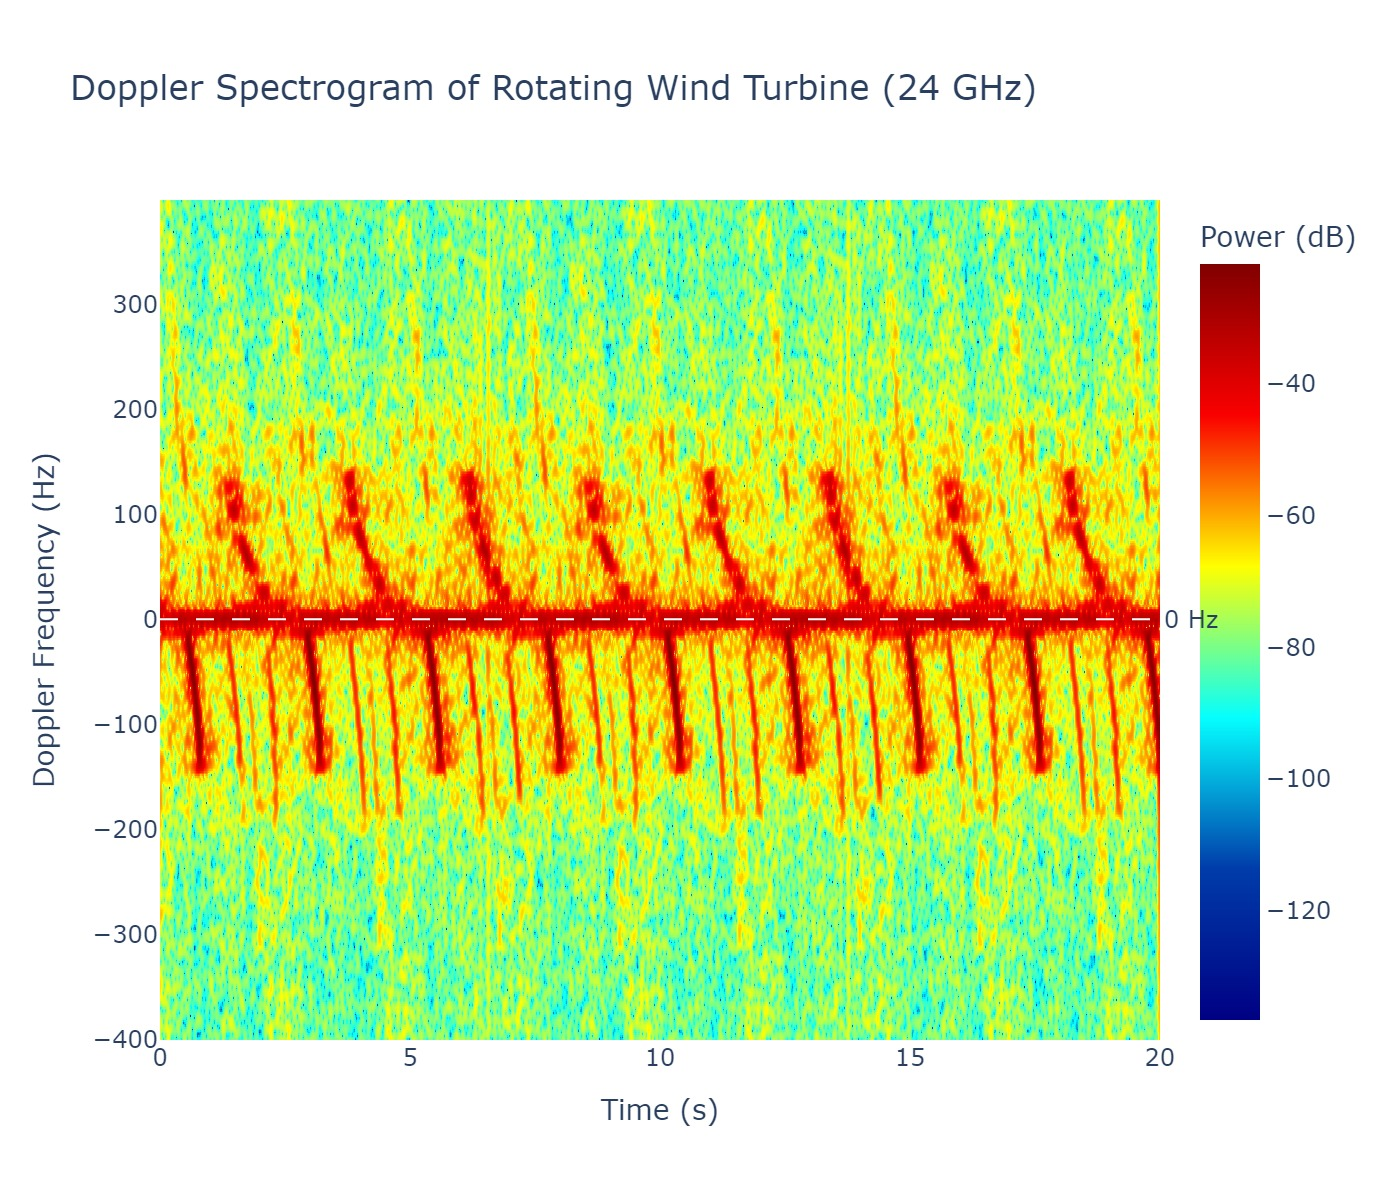

In [11]:
idx_neg = np.where(spec[0] < 0)
idx_pos = np.where(spec[0] >= 0)
dopp_ordered = spec[0][np.concatenate([idx_neg[0], idx_pos[0]])]
spec_shifted = spec[2][np.concatenate([idx_neg[0], idx_pos[0]]), :]

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        z=20 * np.log10(np.abs(spec_shifted)),
        x=spec[1],
        y=dopp_ordered,
        hoverongaps=False,
        colorscale="Jet",
        colorbar=dict(title="Power (dB)"),
    )
)
fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="white",
    line_width=1,
    annotation_text="0 Hz",
    annotation_position="right",
)
fig.update_layout(
    title="Doppler Spectrogram of Rotating Wind Turbine (24 GHz)",
    yaxis=dict(title="Doppler Frequency (Hz)"),
    xaxis=dict(title="Time (s)"),
    height=600,
)

show(fig)

## Summary

- A 24 GHz CW radar observing a rotating turbine produces a characteristic **micro-Doppler spectrogram** with a DC component (stationary tower) and periodic blade flash patterns.
- Blade tip Doppler ≈ 140 Hz; triplet pattern identifies the 3-blade geometry.
- `level="sample"` in `sim_radar` is required for accurate time-varying Doppler — ray tracing per ADC sample captures each instantaneous blade position.
- STFT parameters (window, overlap) trade frequency resolution for time resolution.

### Things to Try

| Experiment | Parameter to change | Observable effect |
|------------|--------------------|--------------------|
| Faster rotation | `50 * timestamp` → `100 * timestamp` | Doppler spread doubles; flashes repeat twice as fast |
| Different frequency | `f=77e9` (W-band) | Doppler scales with frequency: ×3 spread vs. 24 GHz |
| Shorter observation | `t=10` | Fewer rotation cycles; lower Doppler frequency resolution |
| STFT window length | `nperseg=64` or `256` | Observe frequency vs. time resolution trade-off |
| Further turbine | `location=(50, 0, 0)` | Lower SNR; weaker flash contrast |
| Lower ray density | `density=1` | Faster simulation; compare spectrogram quality |

### Resources

- [RadarSimPy Documentation](https://radarsimx.github.io/radarsimpy/index.html)
- [Simulator Module API](https://radarsimx.github.io/radarsimpy/api/sim.html)